# Robustness Checks: Stratified Pilot Sample & Ordering Effects

Draw a stratified pilot sample and use it to pilot-check order effects for whichever axis you're about to run at full scale.

**Ordering Irrelevancy per Axis**: 

The ordering-irrelevance check is done once per axis, on this one shared stratified sample (not redrawn per axis), by running that axis's scoring script with `--ordering-scheme full-factorial` (or `latin-square` for 4+ concept axes) against `dpm_pilot_subsample.csv` below instead of the full corpus. The "dpm_" prefix is historical (built for axis A first) -- the sample itself is generic and gets reused for every axis's pilot check.

## Setup

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import plot_style
from src.reliability import icc_2_1, order_sensitivity
from src.crisis_windows import CRISIS_WINDOWS, resolve_windows, filter_by_window

plot_style.set_style()


## 1) Stratified Pilot Sample

Draws a fixed, reusable pilot subsample once, stratified across `src/crisis_windows.py`'s windows -- not a random slice, since a plain first-N-rows sample would skew toward whichever window happens to come first chronologically (see the reasoning in the original `01_stratified_sample.ipynb`). Re-run this section only if you want a fresh draw (different `RANDOM_STATE`/`PILOT_N`) -- otherwise `dpm_pilot_subsample.csv` already on disk is fine to reuse as-is for a new axis's ordering check.

In [3]:
df_FFF = pd.read_csv("../data/processed/FFF_german.csv", low_memory=False)
df_FFF["creation_time"] = pd.to_datetime(df_FFF["creation_time"], utc=True)
print(f"{len(df_FFF)} posts loaded")


3240 posts loaded


In [4]:
PILOT_N = 1000
RANDOM_STATE = 42

resolved = resolve_windows(CRISIS_WINDOWS, df_FFF["creation_time"].max())
n_per_window = PILOT_N // len(resolved)

pilot_df = (
    pd.concat([
        filter_by_window(df_FFF, w).sample(min(n_per_window, len(filter_by_window(df_FFF, w))), random_state=RANDOM_STATE)
        for w in resolved
    ])
    .drop_duplicates(subset="id")  # windows overlap by design -- a post can get sampled twice
    .reset_index(drop=True)
)
pilot_df.to_csv("../data/processed/dpm_pilot_subsample.csv", index=False)
print(f"{len(pilot_df)} unique posts across {len(resolved)} windows")


985 unique posts across 6 windows


## 2) Ordering / Position Effects

Each `score_texts()` call is stateless -- a fresh API request per (ordering, shard), no memory between documents or between orderings. So this section is **not** checking for some kind of session drift; it's checking a within-prompt serial-position effect: does the *position* a concept is listed in (the instructions block + JSON output schema, built by `ddr`'s `prompt_builder.py`) bias the rating that concept gets, independent of the text actually being scored?

Uses the pilot sample from section 1 above (`data/processed/dpm_pilot_subsample.csv`), scored with `--ordering-scheme full-factorial` (n<=3 concepts) or `--ordering-scheme latin-square` (4+ concepts). The verdict here decides whether the full-corpus run for that axis can safely use a single fixed ordering, or needs counterbalancing too.

### Config

Edit these three lines to switch which axis's pilot-orderings run you're checking, then rerun everything below.

In [5]:
AXIS_NAME = "axis_a_dpm_de"
SCORES_PATH = Path("../data/llm_scores/axis_a_dpm_de_pilot_orderings.csv")
CONCEPT_NAMES = ["diagnostic", "prognostic", "motivational"]


### Load Scores

In [6]:
scores = pd.read_csv(SCORES_PATH, dtype={"text_id": str})
n_orderings = scores["ordering_id"].nunique()
n_posts = scores["text_id"].nunique()
print(f"{len(scores)} rows -- {n_posts} posts x {n_orderings} ordering(s)")
print(f"orderings used: {sorted(scores['ordering'].unique())}")

n_missing = scores[CONCEPT_NAMES].isna().any(axis=1).sum()
print(f"rows with >=1 unparseable concept rating: {n_missing} ({n_missing / len(scores) * 100:.1f}%)")

assert n_orderings > 1, (
    "This section needs a counterbalanced run (--ordering-scheme full-factorial/latin-square), "
    "not a single-ordering one -- point SCORES_PATH at that axis's pilot run."
)


5928 rows -- 988 posts x 6 ordering(s)
orderings used: ['diagnostic,motivational,prognostic', 'diagnostic,prognostic,motivational', 'motivational,diagnostic,prognostic', 'motivational,prognostic,diagnostic', 'prognostic,diagnostic,motivational', 'prognostic,motivational,diagnostic']
rows with >=1 unparseable concept rating: 0 (0.0%)


### Reliability Across Orderings: ICC(2,1)

Treats each ordering like a separate "coder" scoring the same posts (Shrout & Fleiss ICC(2,1), per §6.3.2's reporting plan). High agreement across orderings means the rating is stable regardless of where in the prompt the concept was listed.

In [7]:
icc_by_concept = {}
sensitivity_by_concept = {}

for concept in CONCEPT_NAMES:
    wide = scores.pivot(index="text_id", columns="ordering_id", values=concept).dropna()
    icc_by_concept[concept] = icc_2_1(wide)
    sensitivity_by_concept[concept] = order_sensitivity(wide)

icc_summary = pd.Series(icc_by_concept, name="ICC(2,1)")
print(icc_summary.round(3))
print()
print("Rule of thumb (Cicchetti 1994): <0.40 poor, 0.40-0.59 fair, 0.60-0.74 good, >=0.75 excellent agreement.")


diagnostic      0.950
prognostic      0.883
motivational    0.936
Name: ICC(2,1), dtype: float64

Rule of thumb (Cicchetti 1994): <0.40 poor, 0.40-0.59 fair, 0.60-0.74 good, >=0.75 excellent agreement.


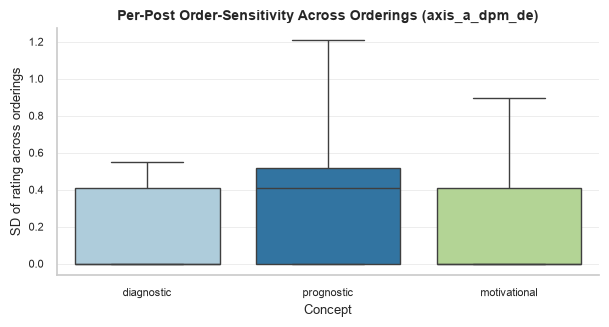

In [8]:
sensitivity_df = pd.DataFrame(sensitivity_by_concept)

fig, ax = plt.subplots(figsize=plot_style.FIGSIZE_WIDE)
sns.boxplot(data=sensitivity_df, ax=ax, showfliers=False)
ax.set_title(f"Per-Post Order-Sensitivity Across Orderings ({AXIS_NAME})")
ax.set_xlabel("Concept")
ax.set_ylabel("SD of rating across orderings")
#plot_style.savefig(fig, f"FFF/{AXIS_NAME}_order_sensitivity")
plt.show()


### Directional Position Effect: Does *Where* a Concept Is Listed Bias Its Rating?

ICC and the SD above show *inconsistency* across orderings, but not *direction* -- a concept could get inconsistent ratings without any systematic primacy/recency pattern, or vice versa. This section checks directly: for each concept, does its mean rating differ depending on which position it was listed in?

For n<=3 concepts (full-factorial), each position is reached via (n-1)! replicate orderings, averaged per post before comparing positions (Friedman's test needs one observation per subject x condition cell). For n=4 (Latin square), each position is reached by exactly 1 ordering, so there's nothing to average -- the same code below handles both cases unchanged.

In [9]:
def ratings_by_position(scores: pd.DataFrame, concept: str) -> pd.DataFrame:
    df = scores.loc[scores[concept].notna(), ["text_id", "ordering", concept]].copy()
    df["position"] = df["ordering"].str.split(",").apply(lambda names: names.index(concept) + 1)
    # averages replicate orderings that place `concept` in the same position (a no-op when
    # there's only 1 replicate, e.g. a Latin-square run)
    return df.groupby(["text_id", "position"])[concept].mean().unstack("position")


position_results = {}
for concept in CONCEPT_NAMES:
    cell = ratings_by_position(scores, concept).dropna()
    stat, p = stats.friedmanchisquare(*[cell[pos] for pos in cell.columns])
    position_results[concept] = {"cell": cell, "friedman_stat": stat, "friedman_p": p}
    means = cell.mean().rename("mean_rating")
    print(f"{concept} (n={len(cell)} posts with all positions):")
    print(means.round(3).to_string())
    print(f"  Friedman chi2={stat:.2f}, p={p:.4f}\n")


diagnostic (n=988 posts with all positions):
position
1    1.592
2    1.607
3    1.560
  Friedman chi2=23.56, p=0.0000

prognostic (n=988 posts with all positions):
position
1    1.423
2    1.460
3    1.474
  Friedman chi2=16.51, p=0.0003

motivational (n=988 posts with all positions):
position
1    3.311
2    3.229
3    3.234
  Friedman chi2=76.72, p=0.0000



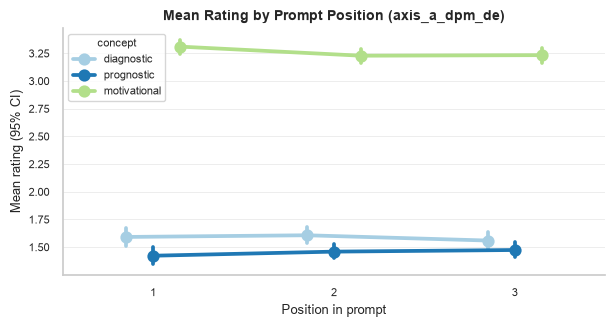

In [10]:
plot_df = pd.concat([
    pd.DataFrame({"concept": concept, "position": position, "rating": res["cell"][position]})
    for concept, res in position_results.items()
    for position in res["cell"].columns
], ignore_index=True)

fig, ax = plt.subplots(figsize=plot_style.FIGSIZE_WIDE)
sns.pointplot(data=plot_df, x="position", y="rating", hue="concept", dodge=0.3, errorbar="ci", ax=ax)
ax.set_title(f"Mean Rating by Prompt Position ({AXIS_NAME})")
ax.set_xlabel("Position in prompt")
ax.set_ylabel("Mean rating (95% CI)")
plot_style.savefig(fig, f"FFF/{AXIS_NAME}_position_effect")
plt.show()


### Verdict

- **ICC(2,1) >= ~0.75 AND Friedman p > .05 for all concepts**: no meaningful position effect -- safe to run the full corpus with `--ordering-scheme single` (fastest, cheapest).
- **Low ICC and/or a significant Friedman result for a concept**: that concept's rating depends on where it's listed -- counterbalance the full-corpus run too for that axis, and use the debiased mean-across-orderings estimate (see `05_llm_scoring_analysis.ipynb`) rather than any single ordering's raw score.

Note: at pilot sample size, even a small, practically-irrelevant position effect can reach statistical significance (Friedman's test grows more sensitive with sample size) -- read the **effect size** (the actual gap between position-means in the plot above, on the concept's rating scale) alongside the p-value, not the p-value alone.

### DPM (Axis A) Result -- Dated Snapshot

The interpretation below is specific to the DPM pilot run (`AXIS_NAME = "axis_a_dpm_de"`) at the time it was run -- it won't update itself if you change `AXIS_NAME` above and rerun for a different axis. Treat it as a record of that run's conclusion, not a live summary; write a fresh version of this cell for each new axis you pilot.

Both things are true at once, and they're not in tension -- they're just answering different questions.

ICC(2,1) (0.88-0.95, "excellent") asks: how much of the total variance in ratings comes from real differences between posts, vs. from which ordering was used? Answer: almost all of it is real between-post signal. That's the more important number for the actual use case (comparing posts/time periods to each other).

Friedman test (p<.001 for all three) asks a much narrower question: is the tiny amount of ordering-driven variance systematically tied to position, or just random noise? Answer: it's systematic, not random -- there is a real, reproducible position effect. But "statistically real" and "big" are different claims, and at n=988 the test has enormous power to detect even trivial effects.

Actual gaps, on the 0-4 scale: diagnostic 0.047, prognostic 0.051, motivational 0.082 (pos 1 vs pos 2/3) -- all under 0.1 points, roughly 1-2% of the scale range. Practical read: statistically real, substantively negligible. Decision made: single ordering for the full DPM corpus run, citing these pilot numbers as justification.